# Clusterizando trayectorias en Ecatepec

In [1]:
import stmeasures
import utils

Y ahora se obtiene el dataset con el que se trabajará

In [2]:
dataset = stmeasures.read_file('../assets/ECATEPEC.json')
trajectories = utils.get_only_trajectories(dataset, 1000)

Y se define el modelo con el que se buscan obtener 10 clusters

In [3]:
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=10, metric='precomputed', linkage='average')

## Euclideano

In [4]:
labels_eu1 = model.fit_predict(utils.compute_distance_matrix(trajectories, utils.euclidean_distance1))

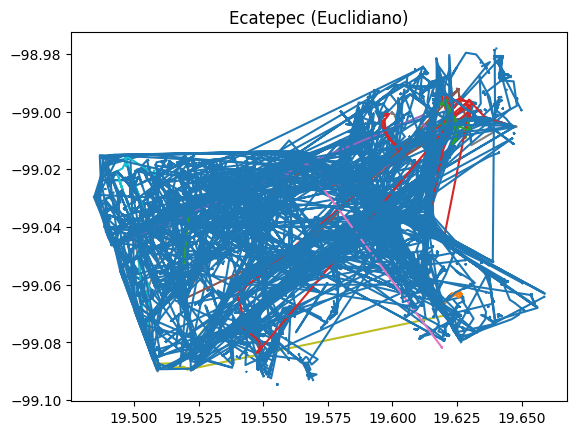

In [5]:
utils.plot_clusters(trajectories, labels_eu1, "Ecatepec (Euclidiano)")

### `Shapely`

In [6]:
labels_eu2 = model.fit_predict(utils.compute_distance_matrix(trajectories, utils.euclidean_distance2))

/home/edev/devel/similarity-measures/venv/lib/python3.12/site-packages/shapely/measurement.py:72: RuntimeWarning: invalid value encountered in distance
  return lib.distance(a, b, **kwargs)


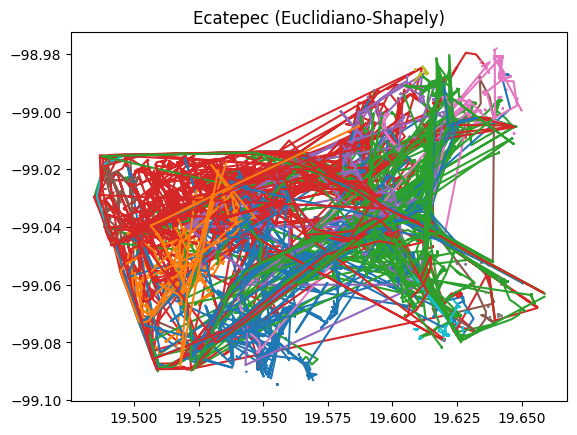

In [7]:
utils.plot_clusters(trajectories, labels_eu2, "Ecatepec (Euclidiano-Shapely)")

## Hausdorff

In [8]:
labels_ha = model.fit_predict(utils.compute_distance_matrix(trajectories, utils.hausdorff_distance))

/home/edev/devel/similarity-measures/venv/lib/python3.12/site-packages/shapely/measurement.py:218: RuntimeWarning: invalid value encountered in hausdorff_distance
  return lib.hausdorff_distance(a, b, **kwargs)


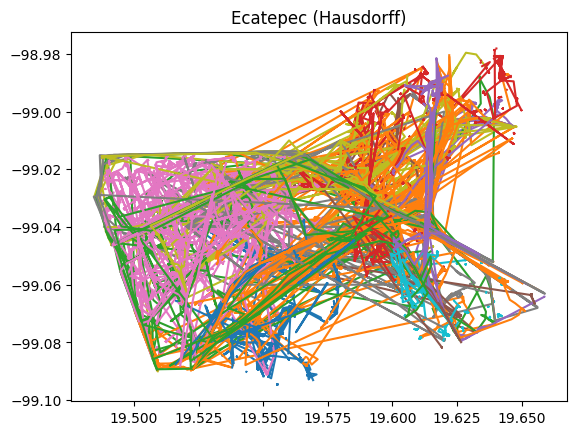

In [9]:
utils.plot_clusters(trajectories, labels_ha, "Ecatepec (Hausdorff)")

## Frechet

In [10]:
labels_fr = model.fit_predict(utils.compute_distance_matrix(trajectories, utils.frechet_distance))

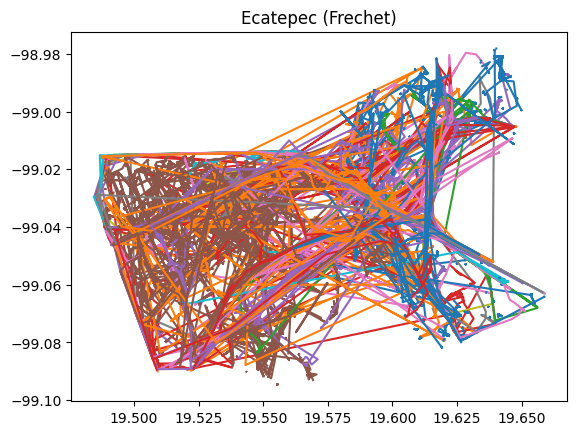

In [11]:
utils.plot_clusters(trajectories, labels_fr, "Ecatepec (Frechet)")

## Spatial Assembling

In [12]:
labels_sp = model.fit_predict(utils.compute_distance_matrix(trajectories, stmeasures.spatialassem_distance))

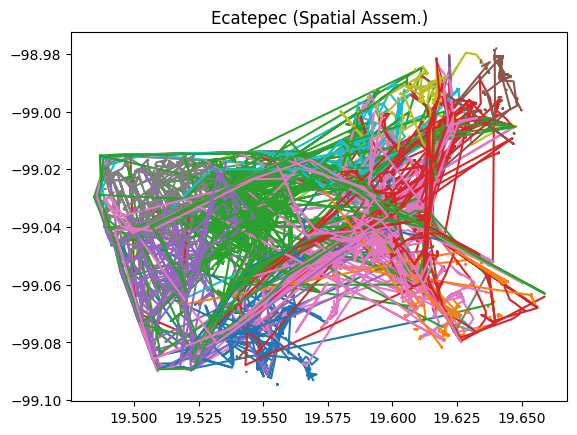

In [13]:
utils.plot_clusters(trajectories, labels_sp, "Ecatepec (Spatial Assem.)")

# Comprobando clusters

Se comprueban estos resultados visualizandolos diréctamente en el mapa

In [25]:
import geojsonio

## Euclidiano

In [23]:
labels_eu1[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2])

In [26]:
_ = geojsonio.display(stmeasures.geojsonio_contents(trajectories=trajectories[18:20], indexes=labels_eu1[18:20]))

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

# Guardando etiquteas

In [14]:
labels_eu1

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [15]:
labels_eu2

array([2, 2, 1, 1, 1, 5, 5, 5, 5, 3, 0, 0, 0, 0, 0, 0, 0, 4, 0, 3, 7, 2,
       2, 3, 3, 3, 2, 2, 6, 6, 6, 0, 2, 2, 2, 3, 8, 3, 2, 2, 3, 3, 0, 0,
       0, 3, 0, 3, 6, 0, 0, 1, 1, 1, 1, 3, 3, 3, 3, 6, 2, 2, 0, 0, 0, 0,
       0, 0, 2, 9, 9, 7, 9, 4, 4, 2, 3, 4, 4, 3, 3, 3, 3, 0, 0, 0, 2, 3,
       3, 0, 2, 3, 2, 2, 4, 2, 2, 2, 3, 1, 1, 1, 1, 2, 0, 0, 0, 0, 0, 0,
       4, 3, 2, 2, 5, 3, 3, 2, 3, 3, 2, 2, 2, 3, 3, 3, 2, 3, 6, 2, 2, 0,
       1, 2, 1, 1, 1, 3, 3, 3, 2, 3, 3, 3, 3, 2, 4, 4, 3, 4, 3, 3, 3, 3,
       0, 0, 0, 2, 3, 3, 2, 2, 3, 3, 3, 3, 3, 0, 0, 2, 2, 2, 2, 2, 2, 3,
       3, 2, 2, 2, 2, 3, 3, 2, 3, 3, 2, 0, 2, 3, 3, 3, 3, 5, 5, 2, 3, 1,
       3, 3, 3, 3, 3, 3, 3, 1, 1, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 1, 7, 5,
       3, 9, 9, 9, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 3, 3, 2, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 2, 0, 2, 0, 2, 0, 2, 1, 1, 3, 3, 3, 3, 0, 2, 2, 2,
       2, 2, 0, 1, 1, 1, 0, 0, 0, 0, 2, 9, 0, 2, 3, 3, 3, 3, 0, 0, 0, 3,
       3, 2, 0, 3, 2, 3, 3, 3, 3, 3, 0, 3, 0, 0, 0,

In [16]:
labels_fr

array([0, 0, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 3, 0, 6, 3, 0, 5,
       1, 5, 5, 5, 0, 0, 0, 0, 0, 6, 1, 0, 0, 1, 0, 1, 0, 4, 5, 3, 5, 5,
       5, 3, 5, 3, 0, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 0, 0, 0, 5, 5, 5, 5,
       5, 5, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 5, 5, 5, 5, 5, 5, 5, 4, 5,
       5, 5, 0, 3, 0, 0, 0, 0, 3, 0, 3, 5, 5, 5, 5, 0, 5, 5, 5, 5, 5, 5,
       0, 3, 6, 4, 8, 4, 3, 8, 6, 6, 5, 5, 9, 5, 5, 1, 9, 4, 0, 0, 0, 5,
       5, 6, 5, 5, 5, 5, 5, 5, 6, 5, 3, 5, 5, 0, 0, 0, 0, 0, 4, 5, 1, 4,
       5, 5, 5, 0, 9, 3, 3, 0, 5, 5, 5, 5, 5, 5, 5, 0, 0, 0, 0, 0, 0, 4,
       6, 7, 0, 3, 0, 4, 1, 3, 1, 4, 3, 3, 0, 6, 0, 3, 3, 5, 5, 1, 6, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 3, 5, 0, 7,
       2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 5, 5, 5, 5, 1, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 4, 5, 4, 5, 6, 5, 6, 5, 5, 5, 5, 5, 5, 1, 6, 0, 0,
       0, 6, 5, 5, 5, 5, 5, 5, 5, 5, 1, 0, 5, 0, 5, 5, 5, 3, 5, 5, 5, 6,
       1, 1, 4, 1, 5, 5, 5, 5, 5, 4, 5, 5, 5, 5, 5,

In [17]:
labels_ha

array([3, 3, 6, 6, 6, 6, 6, 6, 6, 6, 0, 0, 0, 0, 0, 0, 1, 3, 1, 8, 9, 0,
       5, 3, 3, 3, 9, 9, 3, 3, 3, 1, 8, 3, 3, 1, 3, 5, 3, 1, 6, 2, 6, 6,
       6, 2, 6, 1, 3, 1, 1, 6, 6, 6, 6, 6, 6, 6, 6, 3, 9, 9, 6, 6, 6, 6,
       6, 6, 9, 9, 9, 9, 9, 3, 3, 3, 1, 3, 3, 6, 6, 6, 6, 0, 0, 0, 1, 6,
       6, 0, 4, 8, 4, 5, 3, 5, 1, 3, 2, 6, 6, 6, 6, 4, 0, 0, 0, 0, 0, 0,
       3, 7, 7, 8, 7, 8, 8, 1, 7, 2, 3, 3, 7, 6, 6, 8, 7, 8, 3, 3, 3, 0,
       6, 1, 6, 6, 6, 6, 6, 6, 1, 6, 1, 6, 6, 1, 3, 3, 3, 3, 1, 6, 1, 8,
       0, 0, 0, 9, 7, 8, 1, 3, 6, 6, 6, 6, 6, 0, 0, 3, 3, 3, 3, 3, 3, 8,
       7, 7, 4, 7, 4, 8, 1, 1, 8, 8, 8, 2, 4, 8, 3, 8, 1, 6, 6, 1, 1, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 6, 9, 2,
       7, 9, 9, 9, 9, 9, 9, 9, 3, 3, 9, 2, 9, 0, 0, 6, 6, 1, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 1, 0, 1, 6, 1, 0, 1, 6, 6, 6, 6, 6, 6, 7, 1, 3, 3,
       3, 1, 0, 6, 6, 6, 0, 0, 0, 0, 1, 9, 0, 5, 6, 6, 6, 1, 6, 6, 6, 1,
       7, 1, 1, 1, 0, 6, 6, 6, 6, 8, 0, 0, 0, 0, 0,

In [18]:
labels_sp

array([3, 3, 4, 4, 4, 7, 7, 7, 7, 7, 6, 0, 0, 0, 0, 0, 6, 9, 6, 3, 1, 6,
       6, 9, 9, 9, 1, 1, 5, 5, 5, 8, 8, 8, 8, 2, 8, 9, 8, 6, 7, 7, 2, 2,
       2, 4, 2, 2, 5, 0, 0, 4, 4, 4, 4, 2, 2, 2, 2, 5, 6, 6, 2, 2, 2, 2,
       2, 2, 1, 1, 1, 1, 1, 8, 8, 9, 2, 8, 8, 2, 2, 2, 2, 0, 0, 0, 0, 7,
       7, 0, 3, 9, 8, 3, 9, 9, 6, 3, 0, 4, 4, 4, 4, 3, 0, 0, 0, 0, 0, 0,
       8, 6, 6, 2, 2, 2, 9, 2, 2, 2, 6, 6, 2, 2, 2, 2, 2, 2, 5, 3, 3, 0,
       4, 0, 4, 4, 4, 2, 2, 2, 6, 2, 0, 7, 7, 3, 8, 8, 9, 8, 9, 2, 8, 9,
       0, 0, 0, 1, 3, 4, 6, 3, 2, 2, 2, 2, 2, 6, 6, 3, 3, 3, 3, 3, 3, 3,
       2, 2, 3, 2, 3, 9, 9, 9, 9, 9, 2, 0, 3, 8, 6, 2, 2, 7, 7, 0, 9, 4,
       2, 2, 7, 7, 7, 2, 2, 4, 4, 4, 4, 2, 7, 7, 7, 7, 7, 7, 2, 4, 1, 3,
       3, 1, 1, 1, 1, 1, 1, 1, 3, 3, 1, 2, 1, 0, 0, 0, 2, 2, 2, 2, 2, 7,
       2, 2, 2, 2, 4, 3, 0, 6, 2, 0, 0, 6, 4, 4, 7, 7, 7, 7, 6, 3, 3, 3,
       3, 6, 2, 4, 4, 4, 0, 0, 0, 0, 6, 1, 6, 6, 2, 2, 2, 2, 2, 2, 2, 6,
       0, 6, 2, 6, 6, 4, 4, 7, 7, 2, 0, 0, 0, 0, 0,